### Notebook to convert a map in pdf to a geopandas dataframe

In [ ]:
out_dir = 'C:/Users/colin/Downloads/test_pprl/'
path = 'C:/Users/colin/Downloads/test_pprl/map_image.png'

#open PIL image
from PIL import Image
pil_img = Image.open(path)

h, s, v = 255,255,0
# Convert PIL image to numpy array in HSV
hsv_np = np.array(pil_img.convert('HSV'))
# Apply inRange to extract red color
mask = cv2.inRange(hsv_np, (h - 10, s - 40, v - 40), (h + 10, s + 40, v + 40))

#make a small buffer around the mask to not have very difficult geometries
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10,10))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = preprocess_mask(mask)
# plt.figure(figsize=(10, 10))
# mask_plot = mask[::-1,::-1]
# plt.imshow(mask, cmap='gray')

#make the polygons
polygons, labels = extract_polygons_from_mask(mask, label="A")

In [ ]:
import os
import cv2
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from pdf2image import convert_from_path
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk

def convert_pdf_to_image(pdf_path, output_dir):
    images = convert_from_path(pdf_path, dpi=300)
    img_path = os.path.join(output_dir, "map_image.png")
    images[0].save(img_path)
    return img_path

def get_color_mask_from_click(hsv_img, x, y, h_tol=5, s_tol=10, v_tol=10):
    h, s, v = map(int, hsv_img[y, x])
    mask = cv2.inRange(hsv_img, (h-h_tol, s-s_tol, v-v_tol), (h+h_tol, s+s_tol, v+v_tol))

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.dilate(mask, kernel, iterations=1)
    mask = cv2.erode(mask, kernel, iterations=1)

    return mask

def extract_polygons_from_mask(mask, gap_thresh=15):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for cnt in contours:
        coords = [(int(x), int(y)) for [[x, y]] in cnt]
        if len(coords) >= 3:
            polys.append(Polygon(coords))

    if not polys:
        return []

    buffered = [p.buffer(gap_thresh) for p in polys]
    merged = unary_union(buffered)
    cleaned = []

    if isinstance(merged, Polygon):
        cleaned = [merged.buffer(-gap_thresh)]
    elif isinstance(merged, MultiPolygon):
        cleaned = [p.buffer(-gap_thresh) for p in merged.geoms]

    return [p for p in cleaned if p.is_valid and not p.is_empty and p.area > 1]

def show_click_window(img_path, hsv_img):
    clicks = []
    masks = []

    window = tk.Tk()
    window.title("Click zones, then close")

    pil_img = Image.open(img_path)
    tk_img = ImageTk.PhotoImage(pil_img)
    canvas = tk.Canvas(window, width=tk_img.width(), height=tk_img.height())
    canvas.pack()
    canvas.create_image(0, 0, anchor=tk.NW, image=tk_img)

    def on_click(event):
        x, y = event.x, event.y
        clicks.append((x, y))
        mask = get_color_mask_from_click(hsv_img, x, y)
        masks.append(mask)
        canvas.create_oval(x-5, y-5, x+5, y+5, outline='red')

    canvas.bind("<Button-1>", on_click)
    window.mainloop()
    return clicks, masks

def main(pdf_path=None, output_dir=None):
    # Ask for input file if not provided
    if pdf_path is None:
        pdf_path = filedialog.askopenfilename(title="Select PDF Map", filetypes=[("PDF files", "*.pdf")])
        if not pdf_path:
            return

    # Ask for output folder if not provided
    if output_dir is None:
        output_dir = filedialog.askdirectory(title="Choose output folder")
        if not output_dir:
            return

    # Convert PDF to image
    img_path = convert_pdf_to_image(pdf_path, output_dir)
    image = cv2.imread(img_path)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Let user click zones
    clicks, masks = show_click_window(img_path, hsv)

    if not masks:
        messagebox.showerror("No Zones", "No clicks or zones selected.")
        return

    # Extract polygons and save
    all_polys = []
    all_labels = []
    for i, mask in enumerate(masks):
        letter = chr(65 + i)
        polys = extract_polygons_from_mask(mask)
        all_polys.extend(polys)
        all_labels.extend([letter] * len(polys))

    if not all_polys:
        messagebox.showerror("No polygons", "No valid polygons extracted.")
        return

    gdf = gpd.GeoDataFrame({'zone': all_labels, 'geometry': all_polys}, crs="EPSG:32740")
    shp_path = os.path.join(output_dir, "clicked_zones.shp")
    gdf.to_file(shp_path)

    messagebox.showinfo("Done", f"Saved shapefile to:\n{shp_path}")

if __name__ == "__main__":
    out_dir = 'C:/Users/colin/Downloads/test_pprl/'
    path = 'C:/Users/colin/Downloads/test_map.pdf'
    main(pdf_path=path, output_dir=out_dir)


In [64]:
from shapely.ops import unary_union
from shapely.geometry import MultiPolygon

def extract_polygons_from_mask(mask, label="zone", gap_thresh=15):
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    labels = []

    # Convert contours to polygons
    poly_objs = []
    for cnt in contours:
        coords = [(int(x), int(y)) for [[x, y]] in cnt]
        if len(coords) >= 3:
            poly_objs.append(Polygon(coords))

    # Try to join polygons if they are close

    # Buffer by a small amount to join close polygons, then shrink back
    # gap_thresh is in pixels
    if poly_objs:
        # Buffer out, then in
        buffered = [p.buffer(gap_thresh) for p in poly_objs]
        merged = unary_union(buffered)
        # Remove the buffer to restore original shape, but joined
        if isinstance(merged, Polygon):
            merged = [merged.buffer(-gap_thresh)]
        elif isinstance(merged, MultiPolygon):
            merged = [p.buffer(-gap_thresh) for p in merged.geoms]
        else:
            merged = []

        # Filter valid polygons
        for p in merged:
            if p.is_valid and not p.is_empty and p.area > 1:
                polygons.append(p)
                labels.append(label)
    return polygons, labels


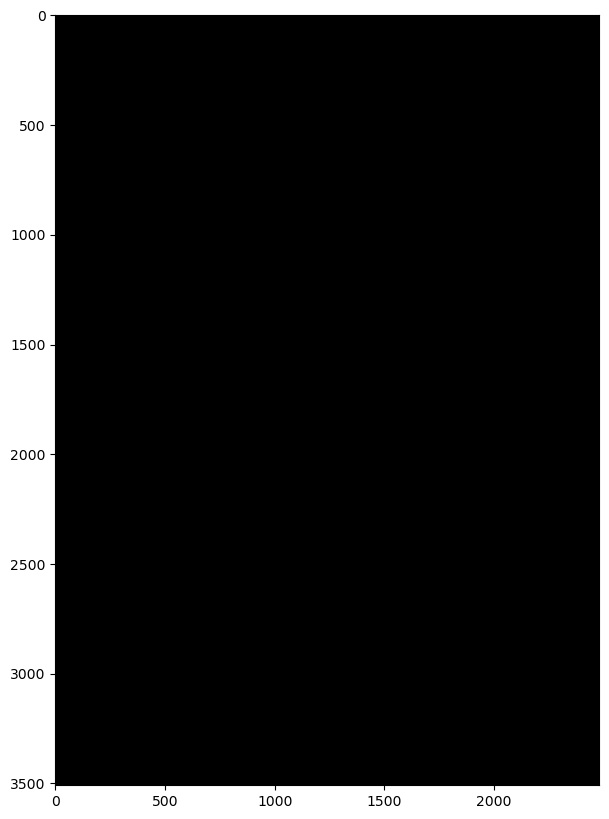

In [ ]:
hsv_list = [(0,255,255),(10,255,255),

plt.figure(figsize=(10, 10))
mask_plot = mask[::-1,:]
plt.imshow(mask_plot, cmap='gray')

C:\Users\colin\AppData\Local\Temp\ipykernel_52148\1578150370.py:5: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  polygons_gdf.plot(column='zone', legend=True, cmap='Set1')


<Axes: >

<Figure size 1000x1000 with 0 Axes>

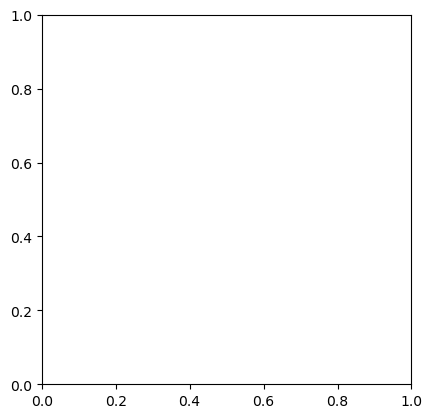

In [76]:
#show the polygons
plt.figure(figsize=(10, 10))

polygons_gdf = gpd.GeoDataFrame({'zone': labels, 'geometry': polygons}, crs="EPSG:32740")
polygons_gdf.plot(column='zone', legend=True, cmap='Set1')

<Axes: >

<Figure size 1000x1000 with 0 Axes>

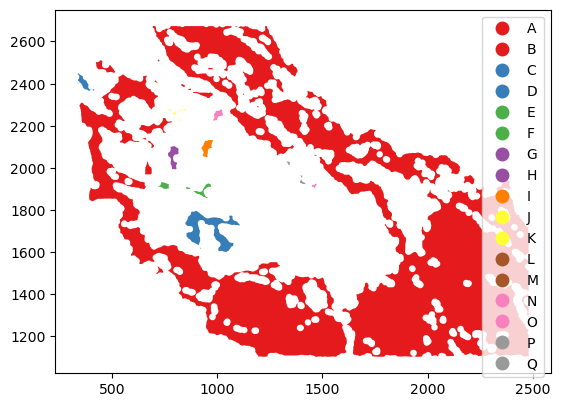

In [78]:
path = 'C:/Users/colin/Downloads/test_pprl/clicked_zones.shp'

import matplotlib.pyplot as plt
import geopandas as gpd
plt.figure(figsize=(10, 10))
import pandas as pd

gpd_zones = gpd.read_file(path)
gpd_zones.plot(column='zone', legend=True, cmap='Set1')

In [14]:
gpd_zones.zone.value_counts().sort_index()

zone
zone    452
Name: count, dtype: int64